In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# Модели с различными

In [1]:
import os
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from sklearn.metrics import accuracy_score

Считываем набор данных

In [2]:
def read_data(path, filename):
    return pd.read_csv(os.path.join(path, filename))

df = read_data(r'C:\Users\USER\OneDrive\Máy tính\Trí tuệ nhân tạo\Lab\Lab_2', 'train.csv')
df.head()

,tBodyAcc-mean()-X,tBodyAcc-mean()-Y,tBodyAcc-mean()-Z,tBodyAcc-std()-X,tBodyAcc-std()-Y,tBodyAcc-std()-Z,tBodyAcc-mad()-X,tBodyAcc-mad()-Y,tBodyAcc-mad()-Z,tBodyAcc-max()-X,...,fBodyBodyGyroJerkMag-kurtosis(),"angle(tBodyAccMean,gravity)","angle(tBodyAccJerkMean),gravityMean)","angle(tBodyGyroMean,gravityMean)","angle(tBodyGyroJerkMean,gravityMean)","angle(X,gravityMean)","angle(Y,gravityMean)","angle(Z,gravityMean)",subject,Activity
0,0.288585,-0.020294,-0.132905,-0.995279,-0.983111,-0.913526,-0.995112,-0.983185,-0.923527,-0.934724,...,-0.710304,-0.112754,0.030400,-0.464761,-0.018446,-0.841247,0.179941,-0.058627,1,STANDING
1,0.278419,-0.016411,-0.123520,-0.998245,-0.975300,-0.960322,-0.998807,-0.974914,-0.957686,-0.943068,...,-0.861499,0.053477,-0.007435,-0.732626,0.703511,-0.844788,0.180289,-0.054317,1,STANDING
2,0.279653,-0.019467,-0.113462,-0.995380,-0.967187,-0.978944,-0.996520,-0.963668,-0.977469,-0.938692,...,-0.760104,-0.118559,0.177899,0.100699,0.808529,-0.848933,0.180637,-0.049118,1,STANDING
3,0.279174,-0.026201,-0.123283,-0.996091,-0.983403,-0.990675,-0.997099,-0.982750,-0.989302,-0.938692,...,-0.482845,-0.036788,-0.012892,0.640011,-0.485366,-0.848649,0.181935,-0.047663,1,STANDING
4,0.276629,-0.016570,-0.115362,-0.998139,-0.980817,-0.990482,-0.998321,-0.979672,-0.990441,-0.942469,...,-0.699205,0.123320,0.122542,0.693578,-0.615971,-0.847865,0.185151,-0.043892,1,STANDING


Теперь, загрузим полный набор данных и сохранить его под следующими четырьмя переменными:

* `train_X`: признаки, используемые для обучения модели
* `train_y`: метки, используемые для обучения модели
* `test_X`: признаки, используемые для проверки модели
* `test_y`: метки, используемые для проверки модели

In [3]:
def load_dataset(label_dict):
    train_X = read_data(r'C:\Users\USER\OneDrive\Máy tính\Trí tuệ nhân tạo\Lab\Lab_2', 'train.csv').values[:,:-2]
    train_y = read_data(r'C:\Users\USER\OneDrive\Máy tính\Trí tuệ nhân tạo\Lab\Lab_2', 'train.csv')['Activity']
    train_y = train_y.map(label_dict).values
    test_X = read_data(r'C:\Users\USER\OneDrive\Máy tính\Trí tuệ nhân tạo\Lab\Lab_2', 'test.csv').values[:,:-2]
    test_y = read_data(r'C:\Users\USER\OneDrive\Máy tính\Trí tuệ nhân tạo\Lab\Lab_2', 'test.csv')
    test_y = test_y['Activity'].map(label_dict).values
    return(train_X, train_y, test_X, test_y)
label_dict = {'WALKING':0, 'WALKING_UPSTAIRS':1, 'WALKING_DOWNSTAIRS':2, 'SITTING':3, 'STANDING':4, 'LAYING':5}
train_X, train_y, test_X, test_y = load_dataset(label_dict)

## Model KNN

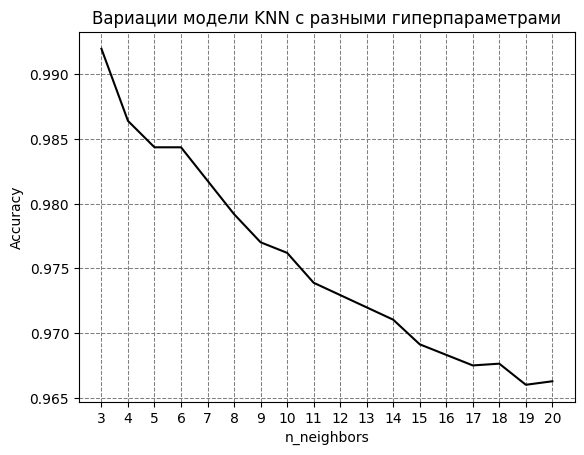

In [14]:
from sklearn.neighbors import KNeighborsClassifier

num_neighbors = np.arange(3, 21)
accuracy = np.zeros(num_neighbors.shape[0])

for i in range(num_neighbors.shape[0]):
    model = KNeighborsClassifier(n_neighbors=num_neighbors[i])
    model.fit(train_X, train_y)

    yhat = model.predict(test_X)

    accuracy[i] = accuracy_score(y_pred=model.predict(train_X), y_true=train_y)

plt.title("Bариации модели KNN с разными гиперпараметрами")
plt.plot(num_neighbors, accuracy, color='black')
plt.xticks(num_neighbors)
plt.grid(linewidth=0.75, linestyle='--')
plt.xlabel('n_neighbors')
plt.ylabel('Accuracy')
plt.grid(color='gray', linewidth=0.75, linestyle='--')
plt.show()

# Model Decision Tree

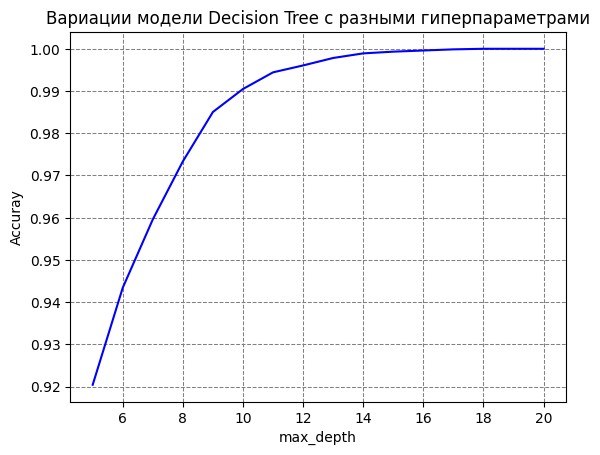

In [12]:
from sklearn.tree import DecisionTreeClassifier

max_depth_range = np.arange(5,21)
accuracy = np.zeros(max_depth_range.shape[0])

for k in range(max_depth_range.shape[0]):
    model = DecisionTreeClassifier(max_depth=max_depth_range[k])
    model.fit(train_X, train_y)

    accuracy[k] = accuracy_score(y_pred=model.predict(train_X), y_true=train_y)

plt.title("Bариации модели Decision Tree с разными гиперпараметрами")
plt.plot(max_depth_range, accuracy, color='blue')
plt.xlabel('max_depth')
plt.ylabel('Accuray')
plt.grid(color='gray', linewidth=0.75, linestyle='--')
plt.show()

# Model SVM

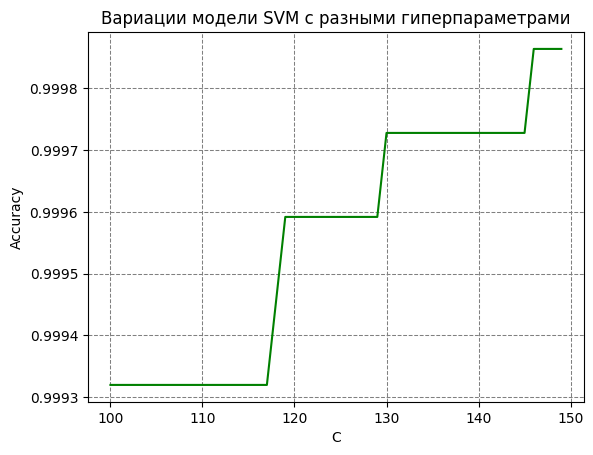

In [13]:
from sklearn.svm import SVC

num_C = np.arange(100, 150)
accuracy = np.zeros(num_C.shape[0])

for c in range(num_C.shape[0]):
    model = SVC(C=num_C[c])
    model.fit(train_X, train_y)

    accuracy[c] = accuracy_score(y_pred=model.predict(train_X), y_true=train_y)

plt.title("Bариации модели SVM с разными гиперпараметрами")
plt.plot(num_C, accuracy, color='green')
plt.grid(linewidth=0.75, linestyle='--')
plt.xlabel('C')
plt.ylabel('Accuracy')
plt.grid(color='gray', linewidth=0.75, linestyle='--')
plt.show()